## Imports

In [2]:
import requests

import pandas as pd
import matplotlib.pyplot as plt


## Client ID

In [3]:
with open(r'C:\Users\stige\Proton Drive\stigep\My files\Data science 2 årig\brukerinfo_meteorologisk.txt', 'r') as f:
    for line in f:
        if line.startswith("Client ID:"):
            client_id = line.split(":")[1].strip()
        else:
            break

## Task 3

##### Compare the 2025 temperatures to the temperatures measured 100 years earlier.

Fetching data from 2025

In [4]:
# Define endpoint and parameters
endpoint = 'https://frost.met.no/observations/v0.jsonld'
parameters = {
    'sources': 'SN17850',
    'elements': 'mean(air_temperature P1D)',
    'referencetime': '2025-01-01/2025-12-31',
}

# Issue an HTTP GET request
r = requests.get(endpoint, parameters, auth=(client_id,''))
# Extract JSON data
json = r.json()

# Check if the request worked, print out any errors
if r.status_code == 200:
    data = json['data']
    print('Data retrieved from frost.met.no!')
else:
    print('Error! Returned status code %s' % r.status_code)
    print('Message: %s' % json['error']['message'])
    print('Reason: %s' % json['error']['reason'])

# Saving to a Pandas df as describes by:
# https://frost.met.no/python_example.html

# This will return a Dataframe with all of the observations in a table format
table = pd.DataFrame()
for i in range(len(data)):
    row = pd.DataFrame(data[i]['observations'])
    row['referenceTime'] = data[i]['referenceTime']
    row['sourceId'] = data[i]['sourceId']
    table = pd.concat([table, row], ignore_index=True)

# These additional columns will be kept
columns = ['sourceId','referenceTime','elementId','value','unit','timeOffset']
df_2025 = table[columns].copy()
# Convert the time value to something Python understands
df_2025['referenceTime'] = pd.to_datetime(df_2025['referenceTime'])


Data retrieved from frost.met.no!


Fetching data from 1925

In [5]:
# Define endpoint and parameters
endpoint = 'https://frost.met.no/observations/v0.jsonld'
parameters = {
    'sources': 'SN17850',
    'elements': 'mean(air_temperature P1D)',
    'referencetime': '1925-01-01/1925-12-31',
}

# Issue an HTTP GET request
r = requests.get(endpoint, parameters, auth=(client_id,''))
# Extract JSON data
json = r.json()

# Check if the request worked, print out any errors
if r.status_code == 200:
    data = json['data']
    print('Data retrieved from frost.met.no!')
else:
    print('Error! Returned status code %s' % r.status_code)
    print('Message: %s' % json['error']['message'])
    print('Reason: %s' % json['error']['reason'])

# Saving to a Pandas df as describes by:
# https://frost.met.no/python_example.html

# This will return a Dataframe with all of the observations in a table format
table = pd.DataFrame()
for i in range(len(data)):
    row = pd.DataFrame(data[i]['observations'])
    row['referenceTime'] = data[i]['referenceTime']
    row['sourceId'] = data[i]['sourceId']
    table = pd.concat([table, row], ignore_index=True)

# These additional columns will be kept
columns = ['sourceId','referenceTime','elementId','value','unit','timeOffset']
df_1925 = table[columns].copy()
# Convert the time value to something Python understands
df_1925['referenceTime'] = pd.to_datetime(df_1925['referenceTime'])


Data retrieved from frost.met.no!


Plotting the 1925 and 2025 data for comparison

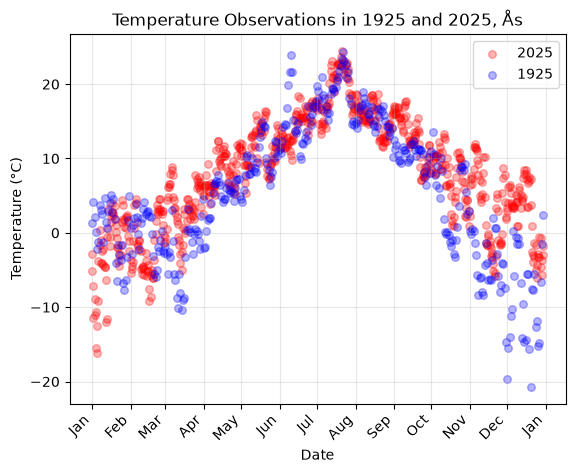

In [31]:
temp_2025 = plt.scatter(df_2025['referenceTime'].dt.dayofyear,
                       df_2025['value'],
                       c='red',
                       s=30,
                       alpha=0.3,
                       label='2025')

temp_2025 = plt.scatter(df_1925['referenceTime'].dt.dayofyear,
                       df_1925['value'],
                       c='blue',
                       s=30,
                       alpha=0.3,
                       label='1925')

plt.grid(True, alpha=0.3, which='both')
plt.xticks([1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335, 366],
           ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
            'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan'],
           rotation=45, ha='right')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.title('Temperature Observations in 1925 and 2025, Ås')
plt.legend()
plt.savefig('Ås_1925_2025_temp_comparison_plot.png', dpi=300, bbox_inches='tight')
plt.show()